# Import & install dependencies

In [ ]:
%pip install kaggle

In [ ]:
!kaggle datasets download darkmatternet/nasa-near-earth-asteroids-and-close-approaches

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

# Load the data

In [20]:
df = pd.read_csv("./src/asteroid_close_approaches_2015_2035.csv")
df.head(10)

,designation,full_name,close_approach_date,distance_au,dist_km,dist_lunar,distance_min_au,distance_max_au,velocity_km_s,v_rel_kmh,velocity_infinity_km_s,absolute_magnitude,is_future
0,2022 AP1,(2022 AP1),2015-01-01 00:27,0.045100,6746806.0,17.55,0.013778,0.076571,11.891749,42810.0,11.886780,28.39,False
1,2015 AE45,(2015 AE45),2015-01-02 15:56,0.048239,7216474.0,18.77,0.048220,0.048258,7.065686,25436.0,7.057864,25.30,False
2,613286,613286 (2005 YQ96),2015-01-02 21:46,0.026522,3967664.0,10.32,0.026522,0.026522,12.703378,45732.0,12.695467,20.63,False
3,2014 YQ34,(2014 YQ34),2015-01-03 13:29,0.079692,11921722.0,31.01,0.078275,0.081108,24.982094,89936.0,24.980756,24.16,False
4,2014 YE42,(2014 YE42),2015-01-03 15:00,0.010995,1644896.0,4.28,0.010971,0.011020,13.998882,50396.0,13.981561,23.40,False
5,2014 YB42,(2014 YB42),2015-01-04 05:33,0.042573,6368882.0,16.57,0.042222,0.042925,9.659652,34775.0,9.653170,25.40,False
6,2014 YP34,(2014 YP34),2015-01-04 10:03,0.022493,3364933.0,8.75,0.022409,0.022578,6.877190,24758.0,6.859944,26.10,False
7,2019 AY3,(2019 AY3),2015-01-04 11:23,0.044703,6687519.0,17.40,0.044703,0.044704,19.790988,71248.0,19.787976,23.82,False
8,85990,85990 (1999 JV6),2015-01-05 11:16,0.083312,12463292.0,32.42,0.083312,0.083312,7.694743,27701.0,7.690586,20.27,False
9,2015 DA363,(2015 DA363),2015-01-06 08:45,0.094326,14110984.0,36.71,0.094232,0.094420,13.585316,48907.0,13.583236,23.32,False


# EDA (Explanatory data analysis)

In [3]:
df.shape

(27430, 13)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27430 entries, 0 to 27429
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   designation             27430 non-null  object 
 1   full_name               27430 non-null  object 
 2   close_approach_date     27430 non-null  object 
 3   distance_au             27430 non-null  float64
 4   dist_km                 27430 non-null  float64
 5   dist_lunar              27430 non-null  float64
 6   distance_min_au         27430 non-null  float64
 7   distance_max_au         27430 non-null  float64
 8   velocity_km_s           27430 non-null  float64
 9   v_rel_kmh               27430 non-null  float64
 10  velocity_infinity_km_s  27413 non-null  float64
 11  absolute_magnitude      27422 non-null  float64
 12  is_future               27430 non-null  bool   
dtypes: bool(1), float64(9), object(3)
memory usage: 2.5+ MB


In [5]:
def missing_values_table(df_):
    # Total missing values
    mis_val = df_.isna().sum()
    
    # Percentage of missing values
    mis_val_percent = 100 * df_.isna().sum() / len(df_)
    
    # Make a table with the results
    mis_val_table = pd.concat([mis_val, mis_val_percent], axis=1)
    
    # Rename the columns
    mis_val_table_ren_columns = mis_val_table.rename(
    columns = {0 : 'Missing Values', 1 : '% of Total Values'})
    
    # Sort the table by percentage of missing descending
    # and filter to only show columns with missing values
    mis_val_table_ren_columns = mis_val_table_ren_columns[
        mis_val_table_ren_columns.iloc[:,1] != 0].sort_values(
        '% of Total Values', ascending=False).round(1)
        
    return mis_val_table_ren_columns


missing_values_table(df)

,Missing Values,% of Total Values
velocity_infinity_km_s,17,0.1
absolute_magnitude,8,0.0


In [21]:
df.dropna(inplace=True)
df.shape

(27405, 13)

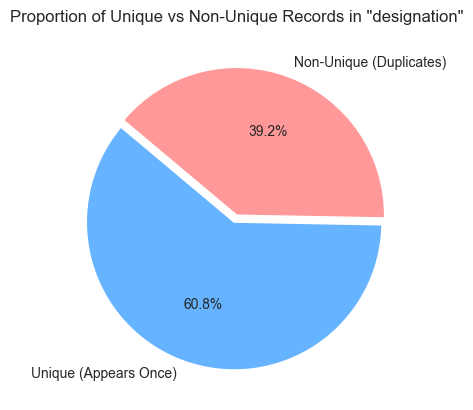

In [7]:
is_duplicate = df['designation'].duplicated(keep=False)

# Count them and map the True/False to readable labels
counts = is_duplicate.value_counts().rename({
    False: 'Unique (Appears Once)', 
    True: 'Non-Unique (Duplicates)'
})

# 3. Create the Pie Plot
counts.plot(
    kind='pie', 
    autopct='%1.1f%%',       # Shows the percentage with 1 decimal place
    startangle=140,          # Rotates the pie slightly for a better look
    colors=['#66b3ff', '#ff9999'], # Custom nice colors
    explode=(0.05, 0)        # Slightly pulls out the first slice for emphasis
)

# 4. Formatting
plt.title('Proportion of Unique vs Non-Unique Records in "designation"')
plt.ylabel('') # Removes the y-label for a cleaner pie chart
plt.show()

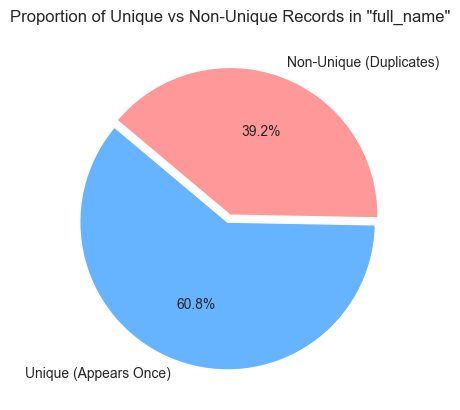

In [8]:
is_duplicate = df['full_name'].duplicated(keep=False)

# Count them and map the True/False to readable labels
counts = is_duplicate.value_counts().rename({
    False: 'Unique (Appears Once)', 
    True: 'Non-Unique (Duplicates)'
})

# 3. Create the Pie Plot
counts.plot(
    kind='pie', 
    autopct='%1.1f%%',       # Shows the percentage with 1 decimal place
    startangle=140,          # Rotates the pie slightly for a better look
    colors=['#66b3ff', '#ff9999'], # Custom nice colors
    explode=(0.05, 0)        # Slightly pulls out the first slice for emphasis
)

# 4. Formatting
plt.title('Proportion of Unique vs Non-Unique Records in "full_name"')
plt.ylabel('') # Removes the y-label for a cleaner pie chart
plt.show()

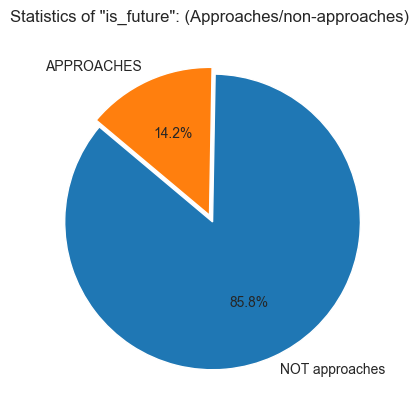

In [9]:
# Count them and map the True/False to readable labels
counts = df["is_future"].value_counts().rename({
    False: 'NOT approaches', 
    True: 'APPROACHES'
})

# 3. Create the Pie Plot
counts.plot(
    kind='pie', 
    autopct='%1.1f%%',       # Shows the percentage with 1 decimal place
    startangle=140,          # Rotates the pie slightly for a better look
    explode=(0.05, 0)        # Slightly pulls out the first slice for emphasis
)

# 4. Formatting
plt.title('Statistics of "is_future": (Approaches/non-approaches)')
plt.ylabel('') # Removes the y-label for a cleaner pie chart
plt.show()

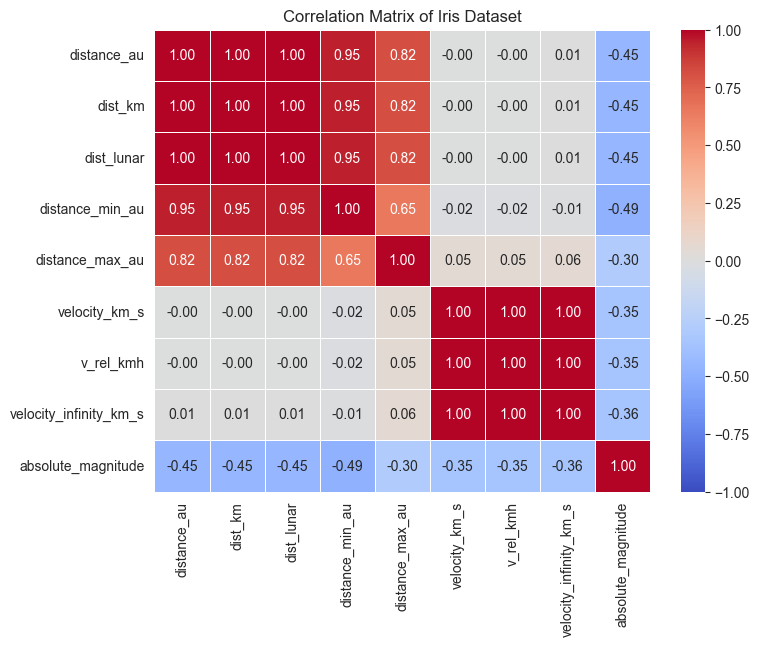

In [10]:
# 1. Isolate numerical columns 
# (Correlation only works on numbers, so we must drop categorical columns)
numeric_df = df.select_dtypes(include=['float64', 'int64'])

# 2. Calculate the correlation matrix using pandas
corr_matrix = numeric_df.corr()

# 3. Plot the heatmap with Seaborn
plt.figure(figsize=(8, 6)) # Sets the size of the plot

sns.heatmap(corr_matrix, 
            annot=True,       # Prints the correlation values inside the boxes
            cmap='coolwarm',  # A good diverging color palette (blue=negative, red=positive)
            vmin=-1, vmax=1,  # Anchors the color scale from -1 to 1 
            fmt='.2f',        # Rounds the numbers to 2 decimal places
            linewidths=0.5)   # Adds a slight grid for readability

# 4. Add a title and display
plt.title('Correlation Matrix of Iris Dataset')
plt.show()

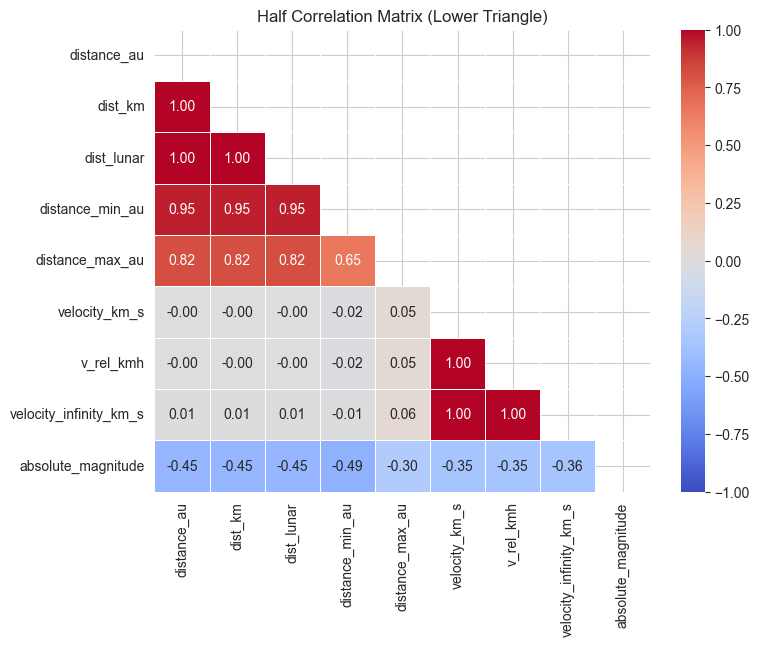

In [11]:
numeric_df = df.select_dtypes(include=['float64', 'int64'])
corr_matrix = numeric_df.corr()

# 2. Create a mask for the upper triangle
# np.ones_like creates an array of True values the same shape as your matrix
# np.triu isolates the upper triangle (True above diagonal, False below)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# 3. Plot the heatmap using the 'mask' parameter
plt.figure(figsize=(8, 6))

sns.heatmap(corr_matrix, 
            mask=mask,        # THIS IS THE NEW LINE
            annot=True, 
            cmap='coolwarm', 
            vmin=-1, vmax=1, 
            fmt='.2f', 
            linewidths=0.5)

plt.title('Half Correlation Matrix (Lower Triangle)')
plt.show()

In [26]:
# Create a new column with actual species names for better plot labels
species_map = {
    True: 'Approaches', 
    False: 'NOT approaches'
}
df['is_future_vis'] = df['is_future'].map(species_map)

df.head()

,designation,full_name,close_approach_date,distance_au,dist_km,dist_lunar,distance_min_au,distance_max_au,velocity_km_s,v_rel_kmh,velocity_infinity_km_s,absolute_magnitude,is_future,is_future_vis
0,2022 AP1,(2022 AP1),2015-01-01 00:27,0.045100,6746806.0,17.55,0.013778,0.076571,11.891749,42810.0,11.886780,28.39,False,NOT approaches
1,2015 AE45,(2015 AE45),2015-01-02 15:56,0.048239,7216474.0,18.77,0.048220,0.048258,7.065686,25436.0,7.057864,25.30,False,NOT approaches
2,613286,613286 (2005 YQ96),2015-01-02 21:46,0.026522,3967664.0,10.32,0.026522,0.026522,12.703378,45732.0,12.695467,20.63,False,NOT approaches
3,2014 YQ34,(2014 YQ34),2015-01-03 13:29,0.079692,11921722.0,31.01,0.078275,0.081108,24.982094,89936.0,24.980756,24.16,False,NOT approaches
4,2014 YE42,(2014 YE42),2015-01-03 15:00,0.010995,1644896.0,4.28,0.010971,0.011020,13.998882,50396.0,13.981561,23.40,False,NOT approaches


In [27]:
df.columns

Index(['designation', 'full_name', 'close_approach_date', 'distance_au',
       'dist_km', 'dist_lunar', 'distance_min_au', 'distance_max_au',
       'velocity_km_s', 'v_rel_kmh', 'velocity_infinity_km_s',
       'absolute_magnitude', 'is_future', 'is_future_vis'],
      dtype='object')

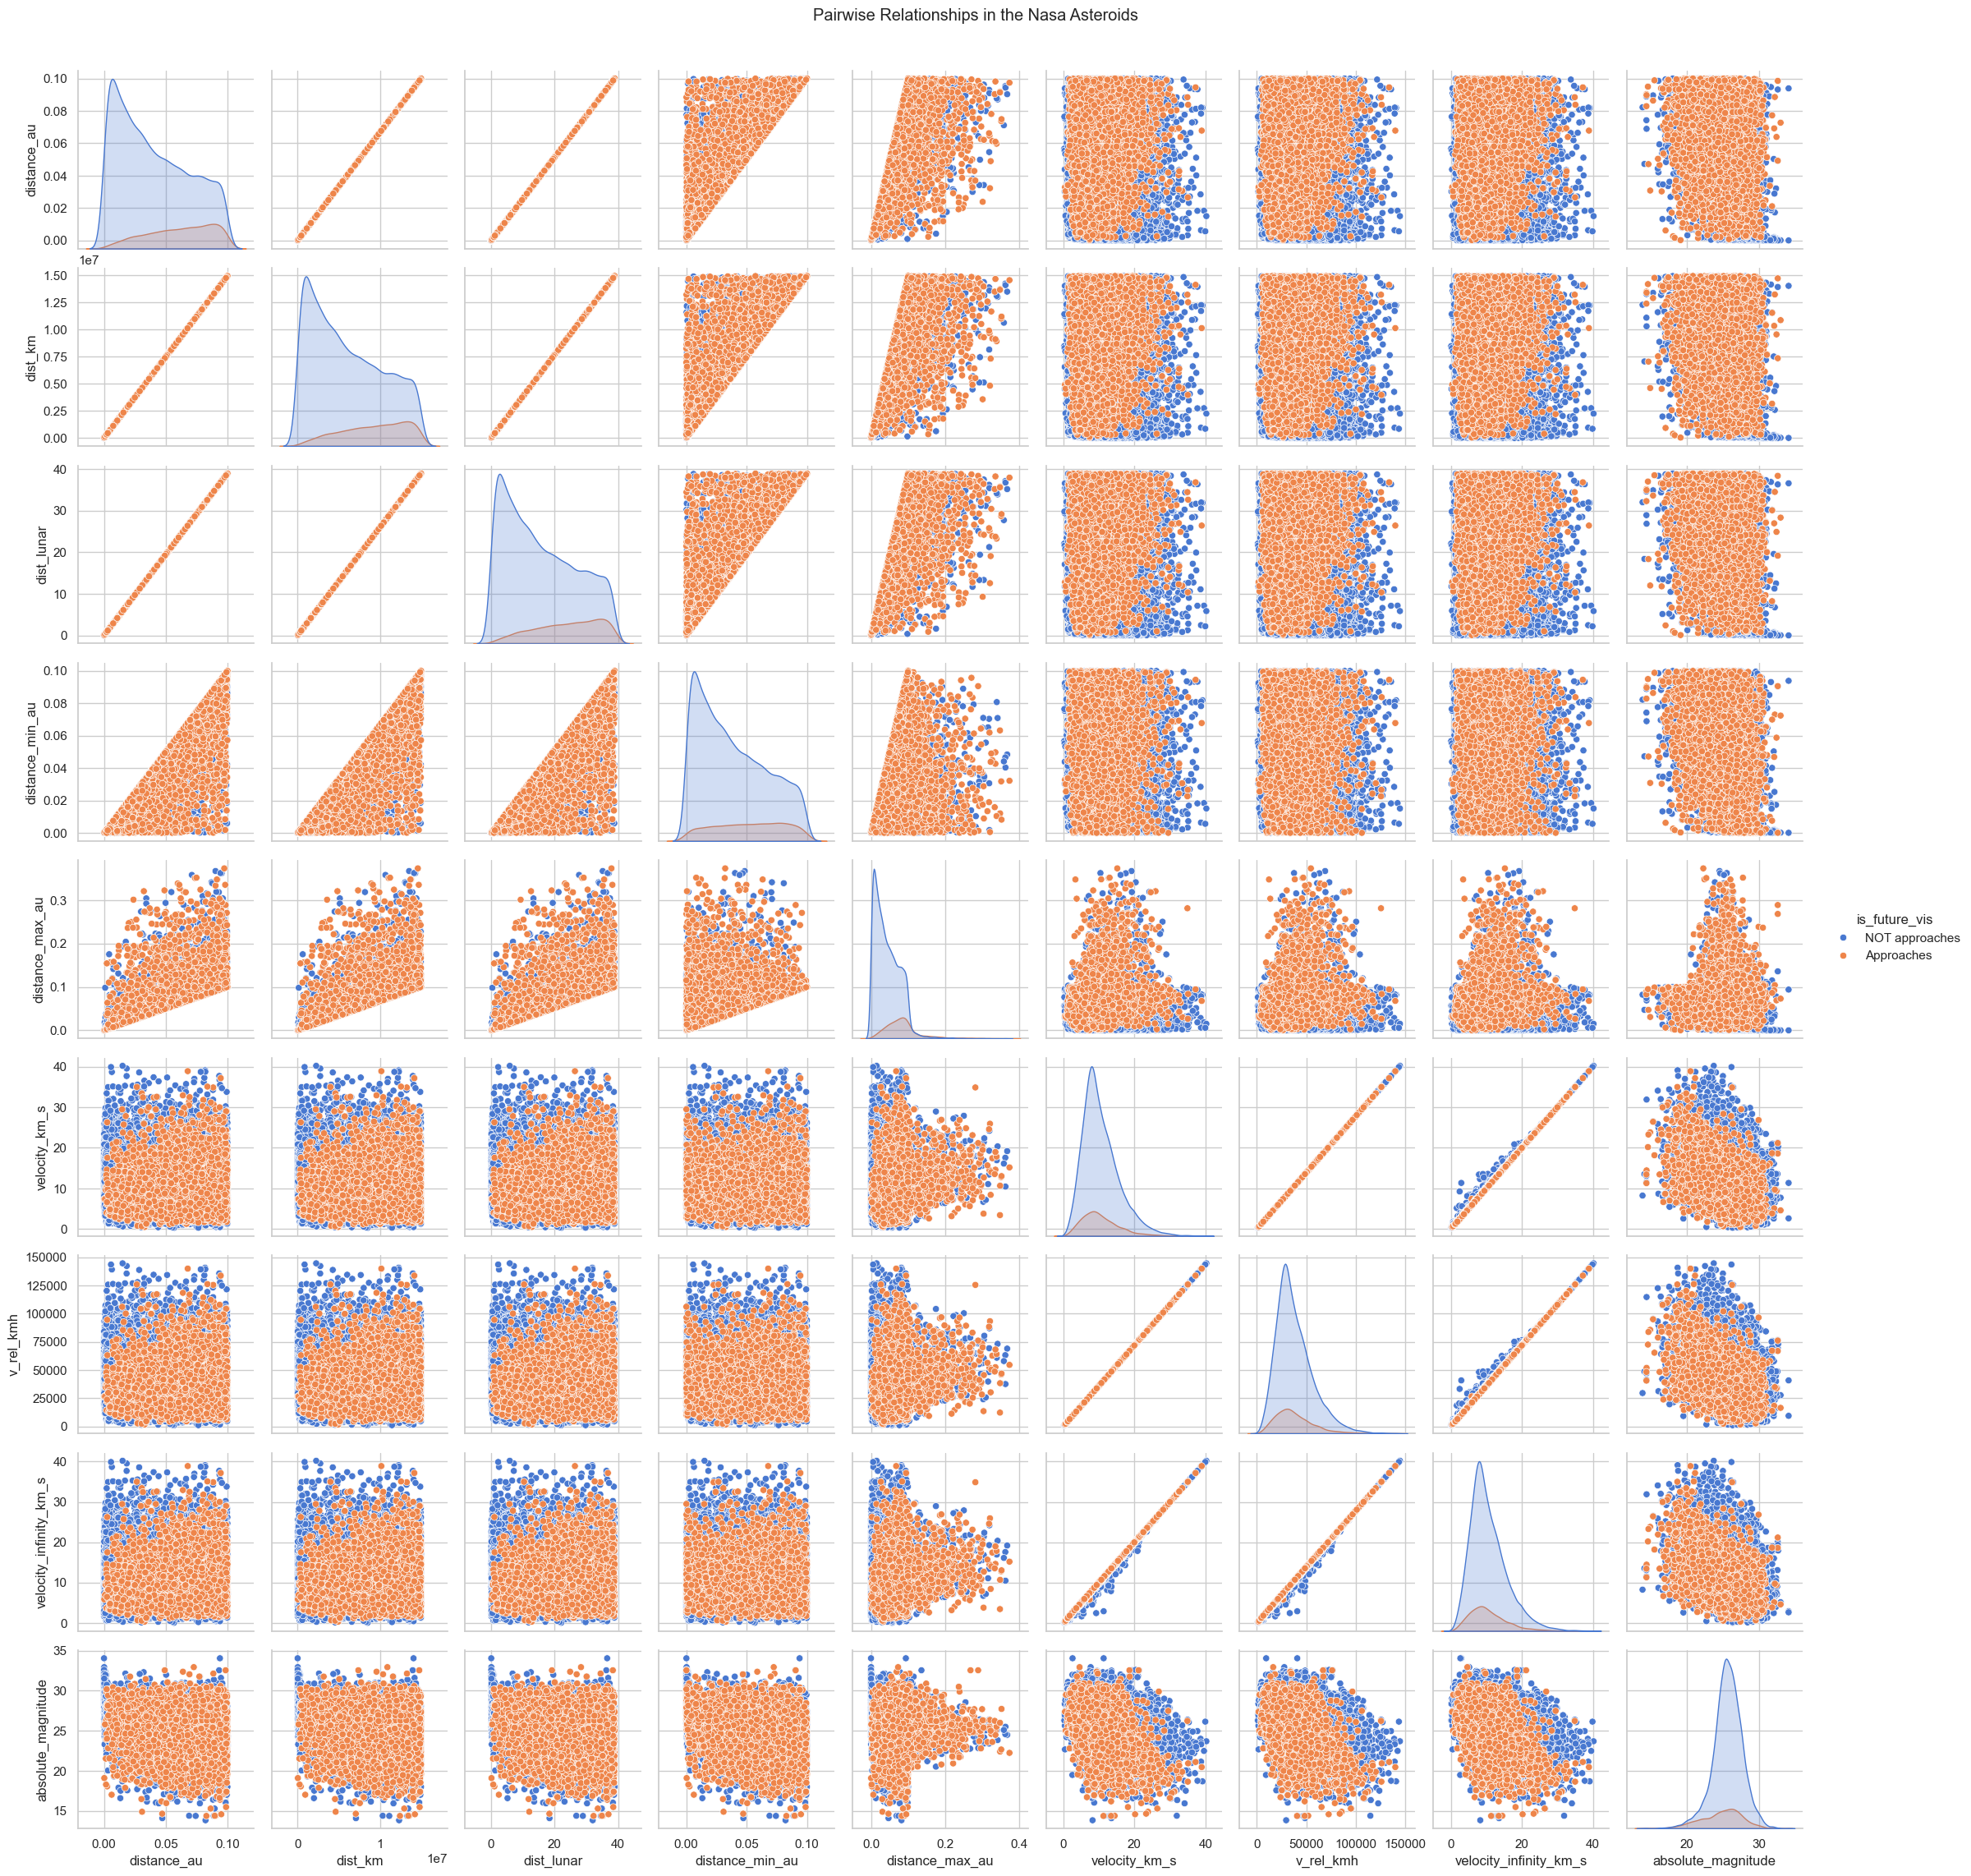

In [29]:
# Apply a Seaborn theme. This instantly upgrades the look of all our plots.
sns.set_theme(style="whitegrid", palette="muted")

# The 'hue' parameter automatically colors the data points by species.
sns.pairplot(df[[
    'designation', 'full_name', 'close_approach_date', 'distance_au',
    'dist_km', 'dist_lunar', 'distance_min_au', 'distance_max_au',
    'velocity_km_s', 'v_rel_kmh', 'velocity_infinity_km_s',
    'absolute_magnitude', 'is_future_vis'
]], hue='is_future_vis', height=2.5)

# Matplotlib functions still work to tweak Seaborn plots!
plt.suptitle('Pairwise Relationships in the Nasa Asteroids', y=1.02)
plt.show()

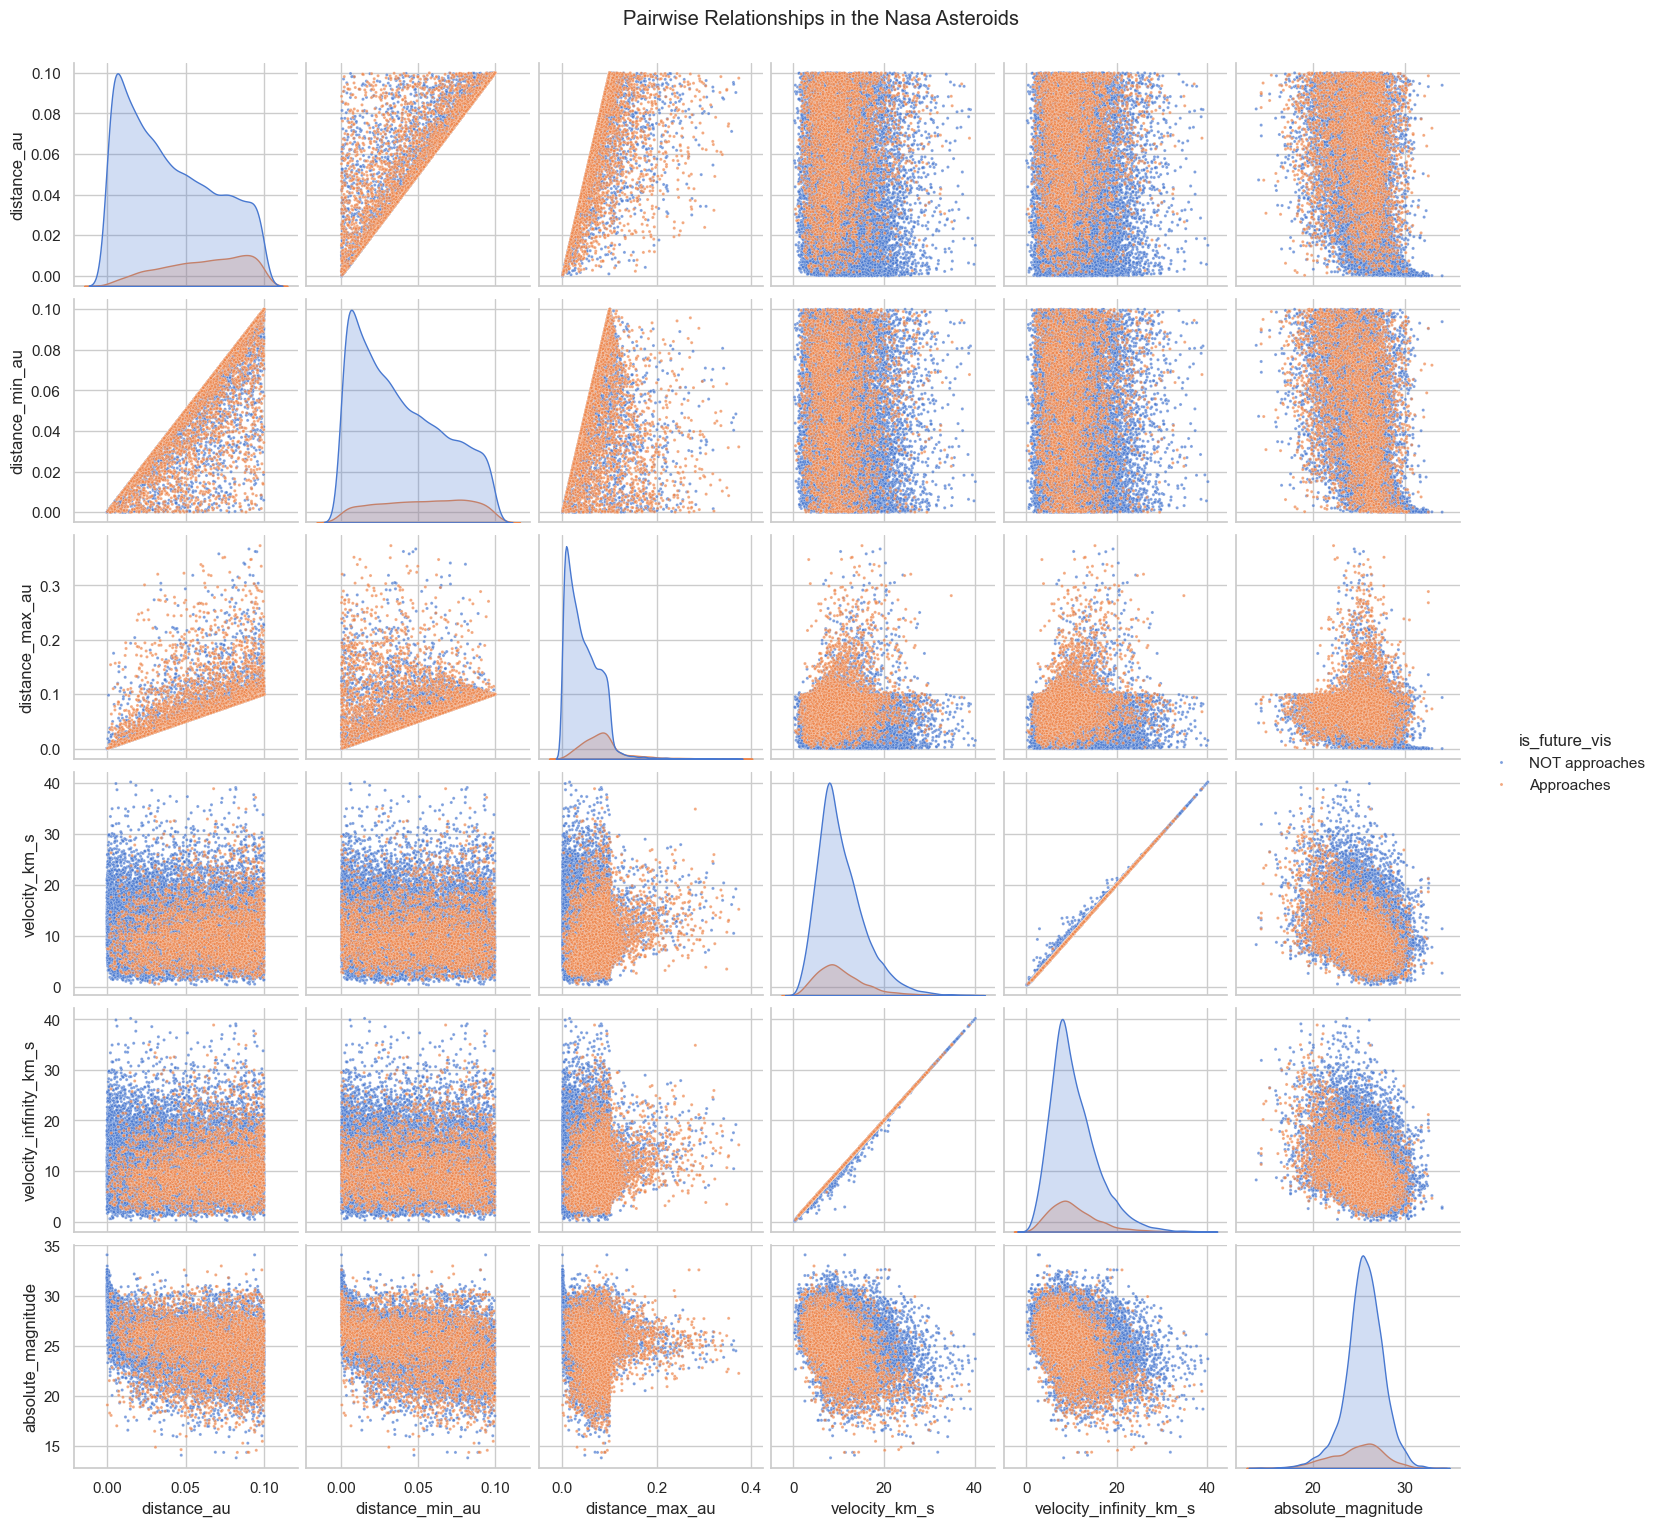

In [33]:
# Apply a Seaborn theme. This instantly upgrades the look of all our plots.
sns.set_theme(style="whitegrid", palette="muted")

# The 'hue' parameter automatically colors the data points by species.
sns.pairplot(df[[
    'distance_au', 'distance_min_au', 'distance_max_au',
    'velocity_km_s', 'velocity_infinity_km_s',
    'absolute_magnitude', 'is_future_vis'
]], hue='is_future_vis', height=2.5, plot_kws={'s': 5, 'alpha': 0.7})

# Matplotlib functions still work to tweak Seaborn plots!
plt.suptitle('Pairwise Relationships in the Nasa Asteroids', y=1.02)
plt.show()

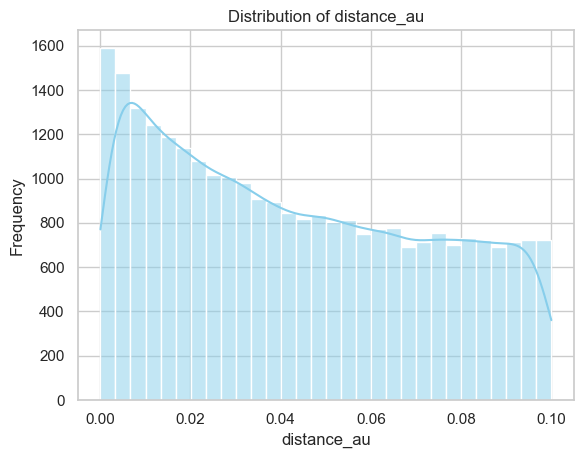

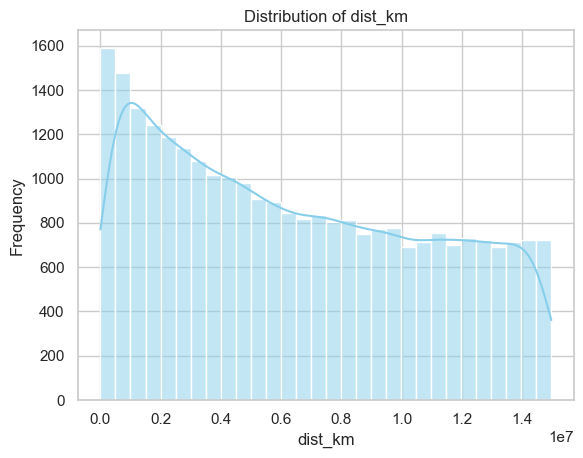

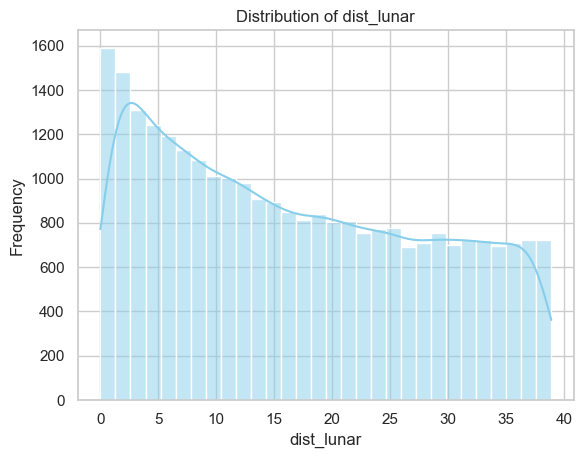

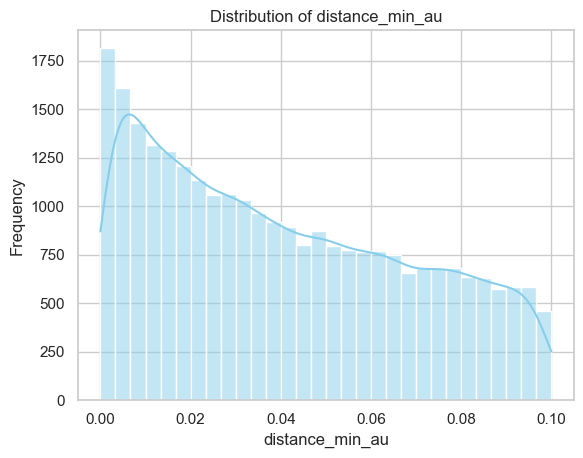

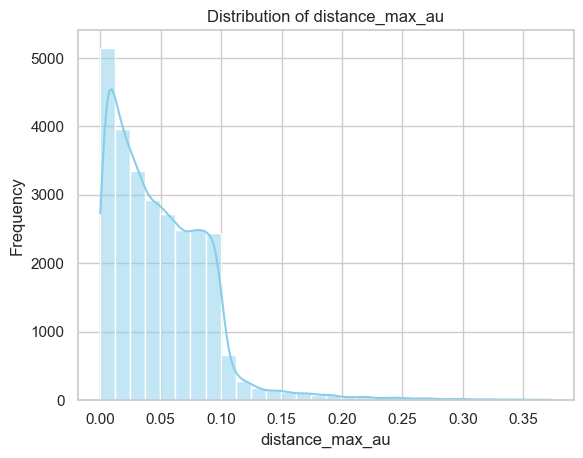

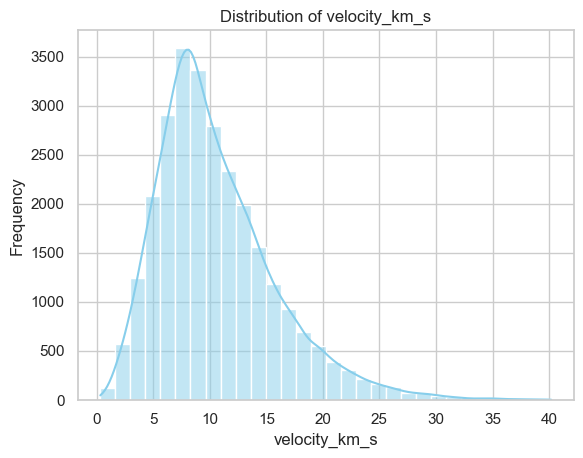

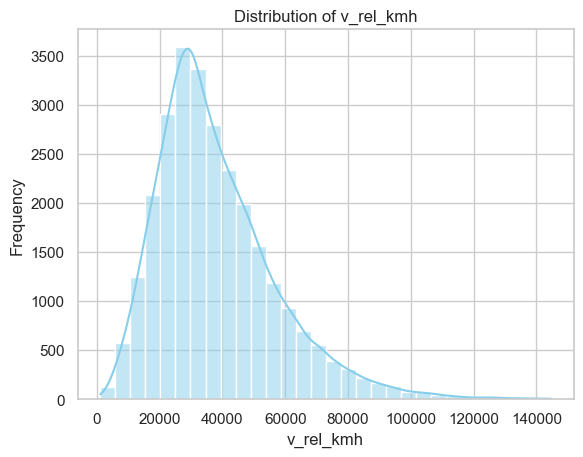

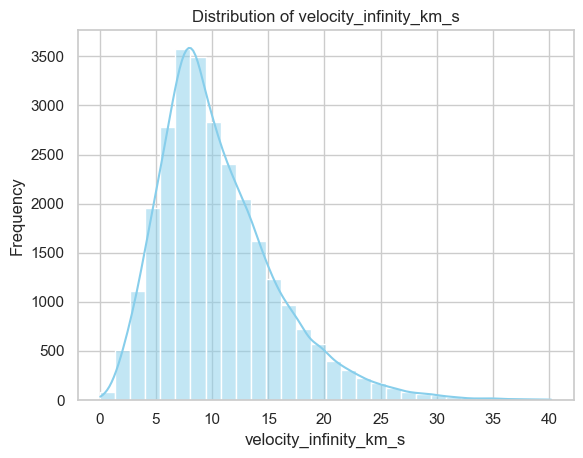

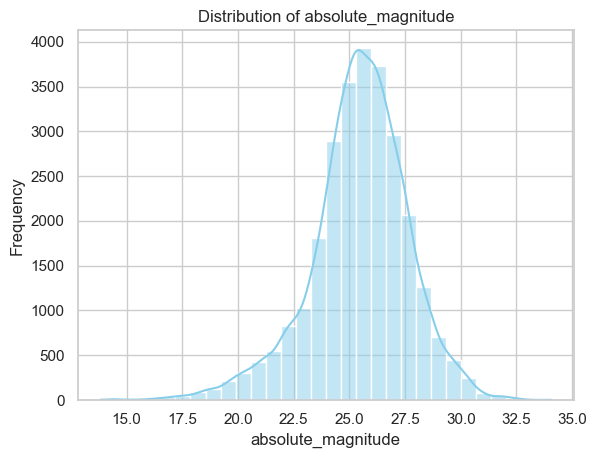

In [38]:
for feat_name in ['distance_au', 'dist_km', 'dist_lunar', 'distance_min_au', 'distance_max_au','velocity_km_s', 'v_rel_kmh', 'velocity_infinity_km_s', 'absolute_magnitude']:
    # Apply the theme
    sns.set_theme(style="whitegrid")
    
    # Plot the distribution
    sns.histplot(
        data=df, 
        x=feat_name, 
        kde=True,       # Adds the smooth curve
        bins=30,        # Number of bars (adjust this to see more/less detail)
        color='skyblue'
    )
    
    plt.title(f'Distribution of {feat_name}')
    plt.xlabel(feat_name)
    plt.ylabel('Frequency')
    plt.show()

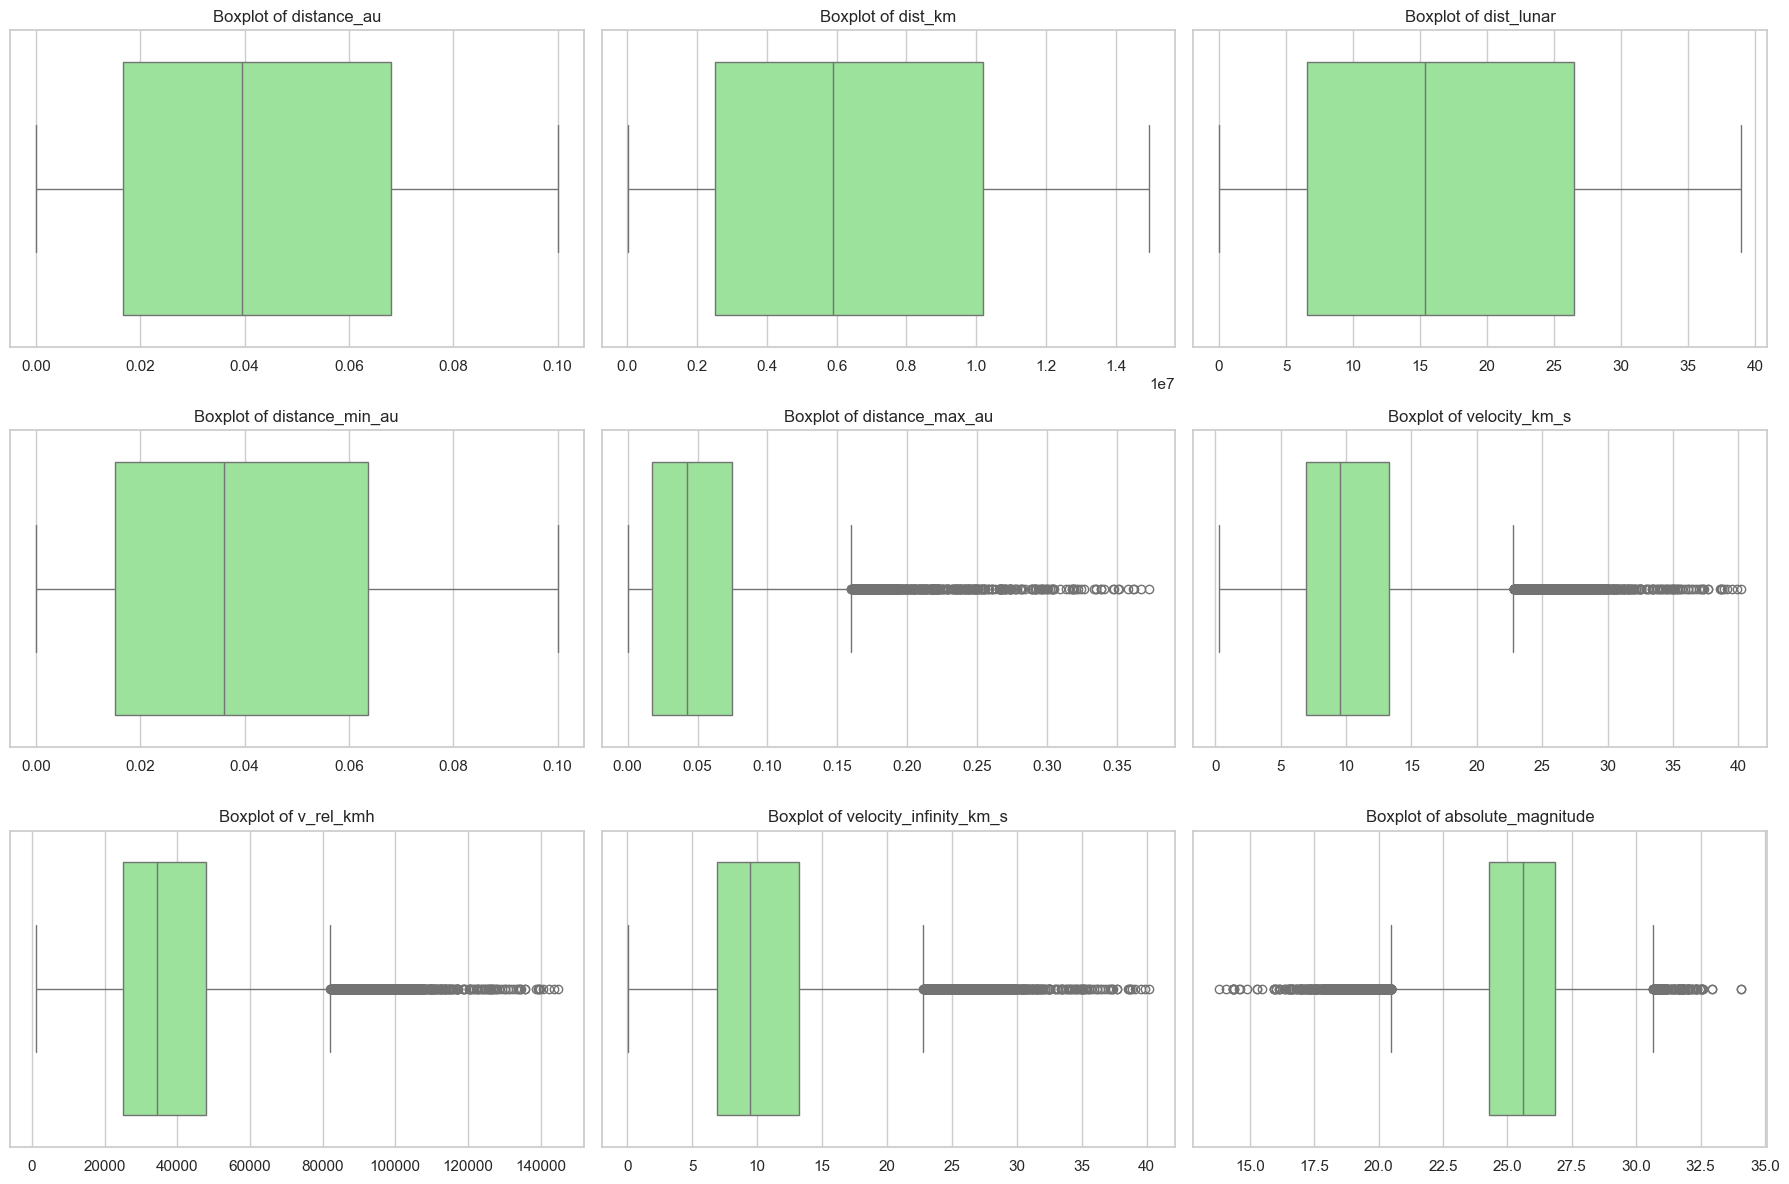

In [40]:
features = [
    'distance_au', 'dist_km', 'dist_lunar', 'distance_min_au', 
    'distance_max_au', 'velocity_km_s', 'v_rel_kmh', 
    'velocity_infinity_km_s', 'absolute_magnitude'
]

# 1. Create a 3x3 grid of subplots
# figsize=(15, 10) makes the overall canvas large enough to read clearly
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(18, 12))

# 2. Flatten the 3x3 grid array into a 1D list so we can loop through it easily
axes = axes.flatten()

# 3. Loop through your features and plot them on their designated axis
for i, feat_name in enumerate(features):
    sns.boxplot(
        data=df, 
        x=feat_name, 
        color='lightgreen',
        ax=axes[i]  # THIS is the magic line that assigns the plot to a grid slot
    )
    
    axes[i].set_title(f'Boxplot of {feat_name}')
    axes[i].set_xlabel('') # Clears the x-label since the title already says it

# 4. Clean up the layout and display
plt.tight_layout() # Automatically adjusts spacing so titles/labels don't overlap
plt.show()

In [43]:
df.describe()

,distance_au,dist_km,dist_lunar,distance_min_au,distance_max_au,velocity_km_s,v_rel_kmh,velocity_infinity_km_s,absolute_magnitude
count,27405.000000,2.740500e+04,27405.000000,27405.000000,27405.000000,27405.000000,27405.000000,27405.000000,27405.000000
mean,0.043278,6.474280e+06,16.842426,0.040467,0.049549,10.560125,38016.452399,10.527736,25.451230
std,0.029510,4.414574e+06,11.484231,0.028635,0.040627,5.235098,18846.355228,5.243725,2.207512
min,0.000044,6.599000e+03,0.020000,0.000000,0.000044,0.308789,1112.000000,0.036680,13.820000
25%,0.016800,2.513295e+06,6.540000,0.015054,0.017488,6.929909,24948.000000,6.896876,24.300000
50%,0.039490,5.907602e+06,15.370000,0.035953,0.042557,9.526236,34294.000000,9.492726,25.590000
75%,0.068109,1.018893e+07,26.510000,0.063576,0.074501,13.286089,47830.000000,13.258927,26.840000
max,0.099993,1.495878e+07,38.910000,0.099992,0.373051,40.190937,144687.000000,40.186533,34.060000


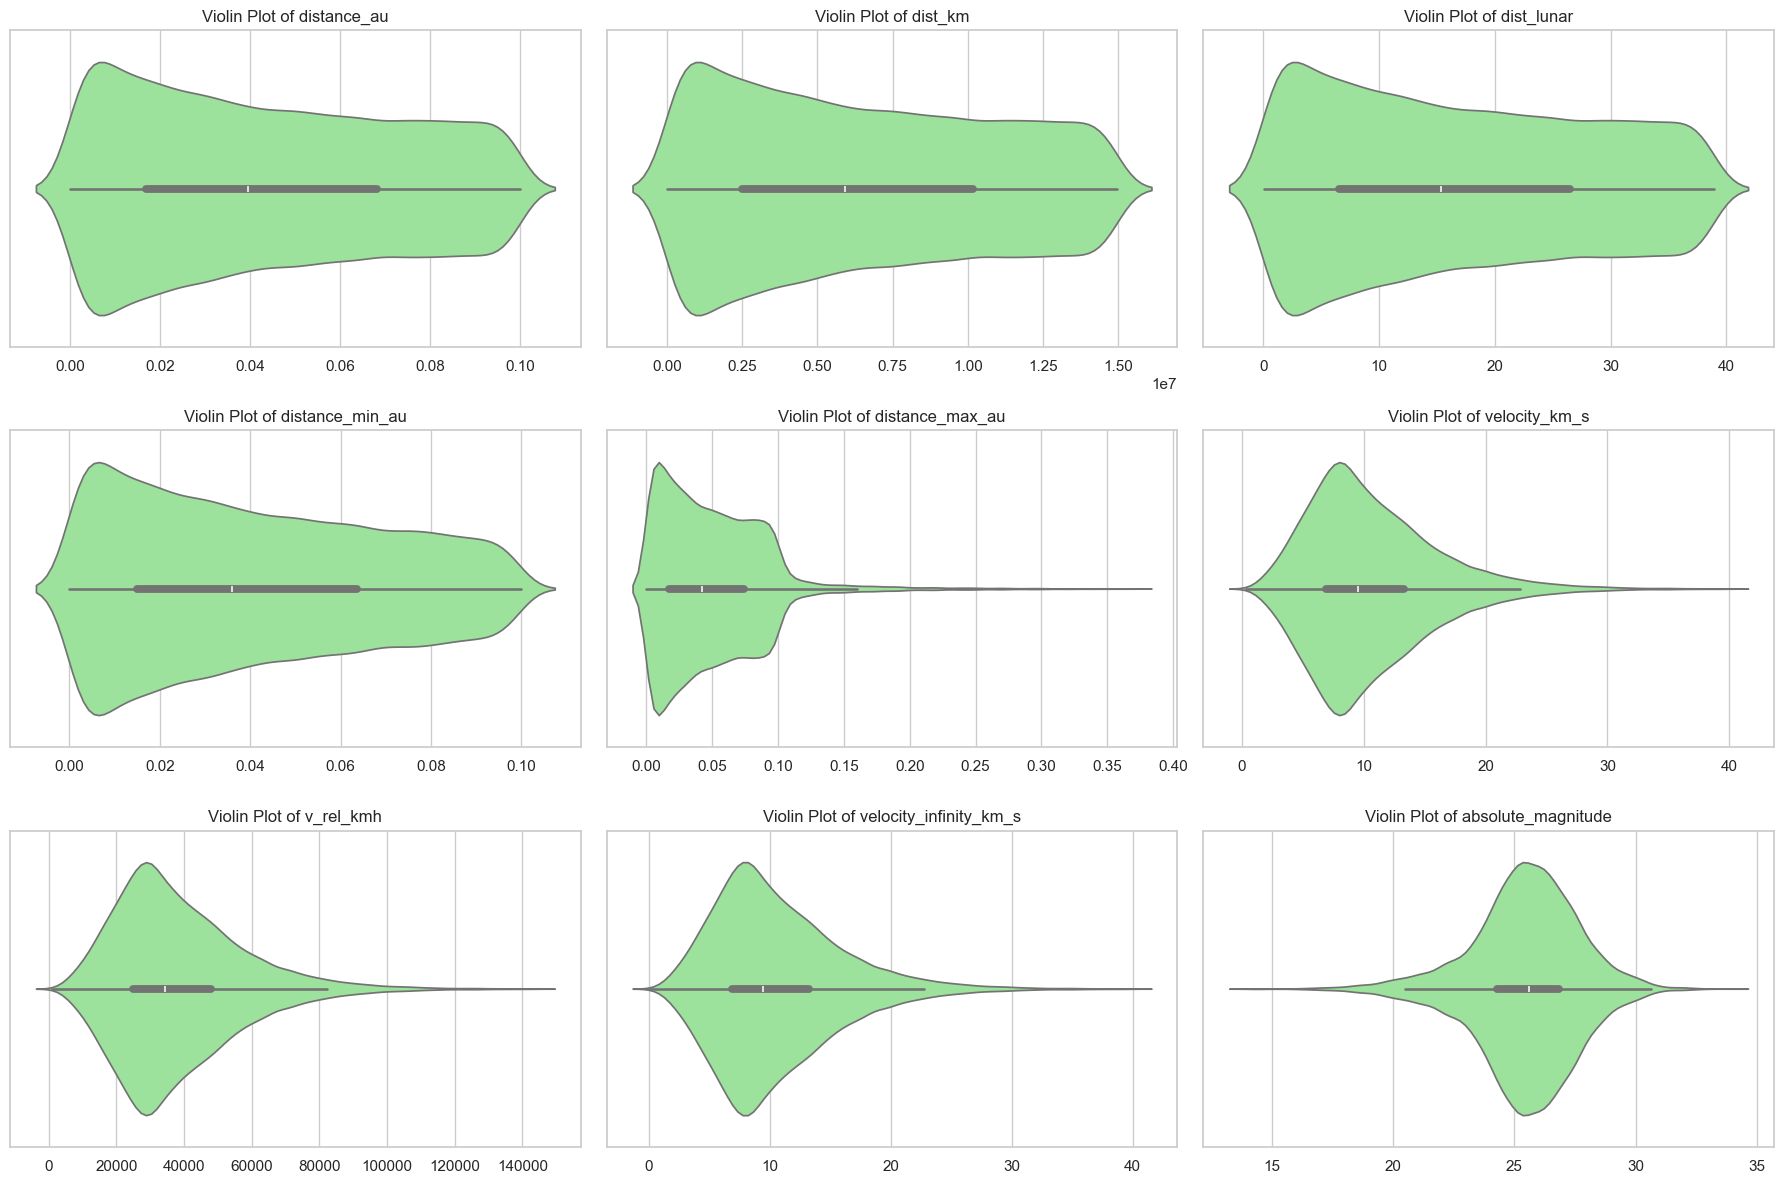

In [41]:
# 1. List the features again for clarity within this combined approach
features = [
    'distance_au', 'dist_km', 'dist_lunar', 'distance_min_au', 
    'distance_max_au', 'velocity_km_s', 'v_rel_kmh', 
    'velocity_infinity_km_s', 'absolute_magnitude'
]

# 2. Create the grid of subplots (same as before)
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(18, 12))

# 3. Flatten the axes array (same as before)
axes = axes.flatten()

# 4. Loop through your features and plot them (adapted for violin plots)
for i, feat_name in enumerate(features):
    sns.violinplot(
        data=df, 
        x=feat_name, 
        color='lightgreen', # Consistent color choice
        ax=axes[i],
        inner="box" # Shows box plot elements inside (default)
        # you can also combine options, e.g., inner=("box", "quartile")
    )
    
    axes[i].set_title(f'Violin Plot of {feat_name}')
    axes[i].set_xlabel('') # Optional: Clear x-label since title covers it

# 5. Final layout adjustments (same as before)
plt.tight_layout()
plt.show()

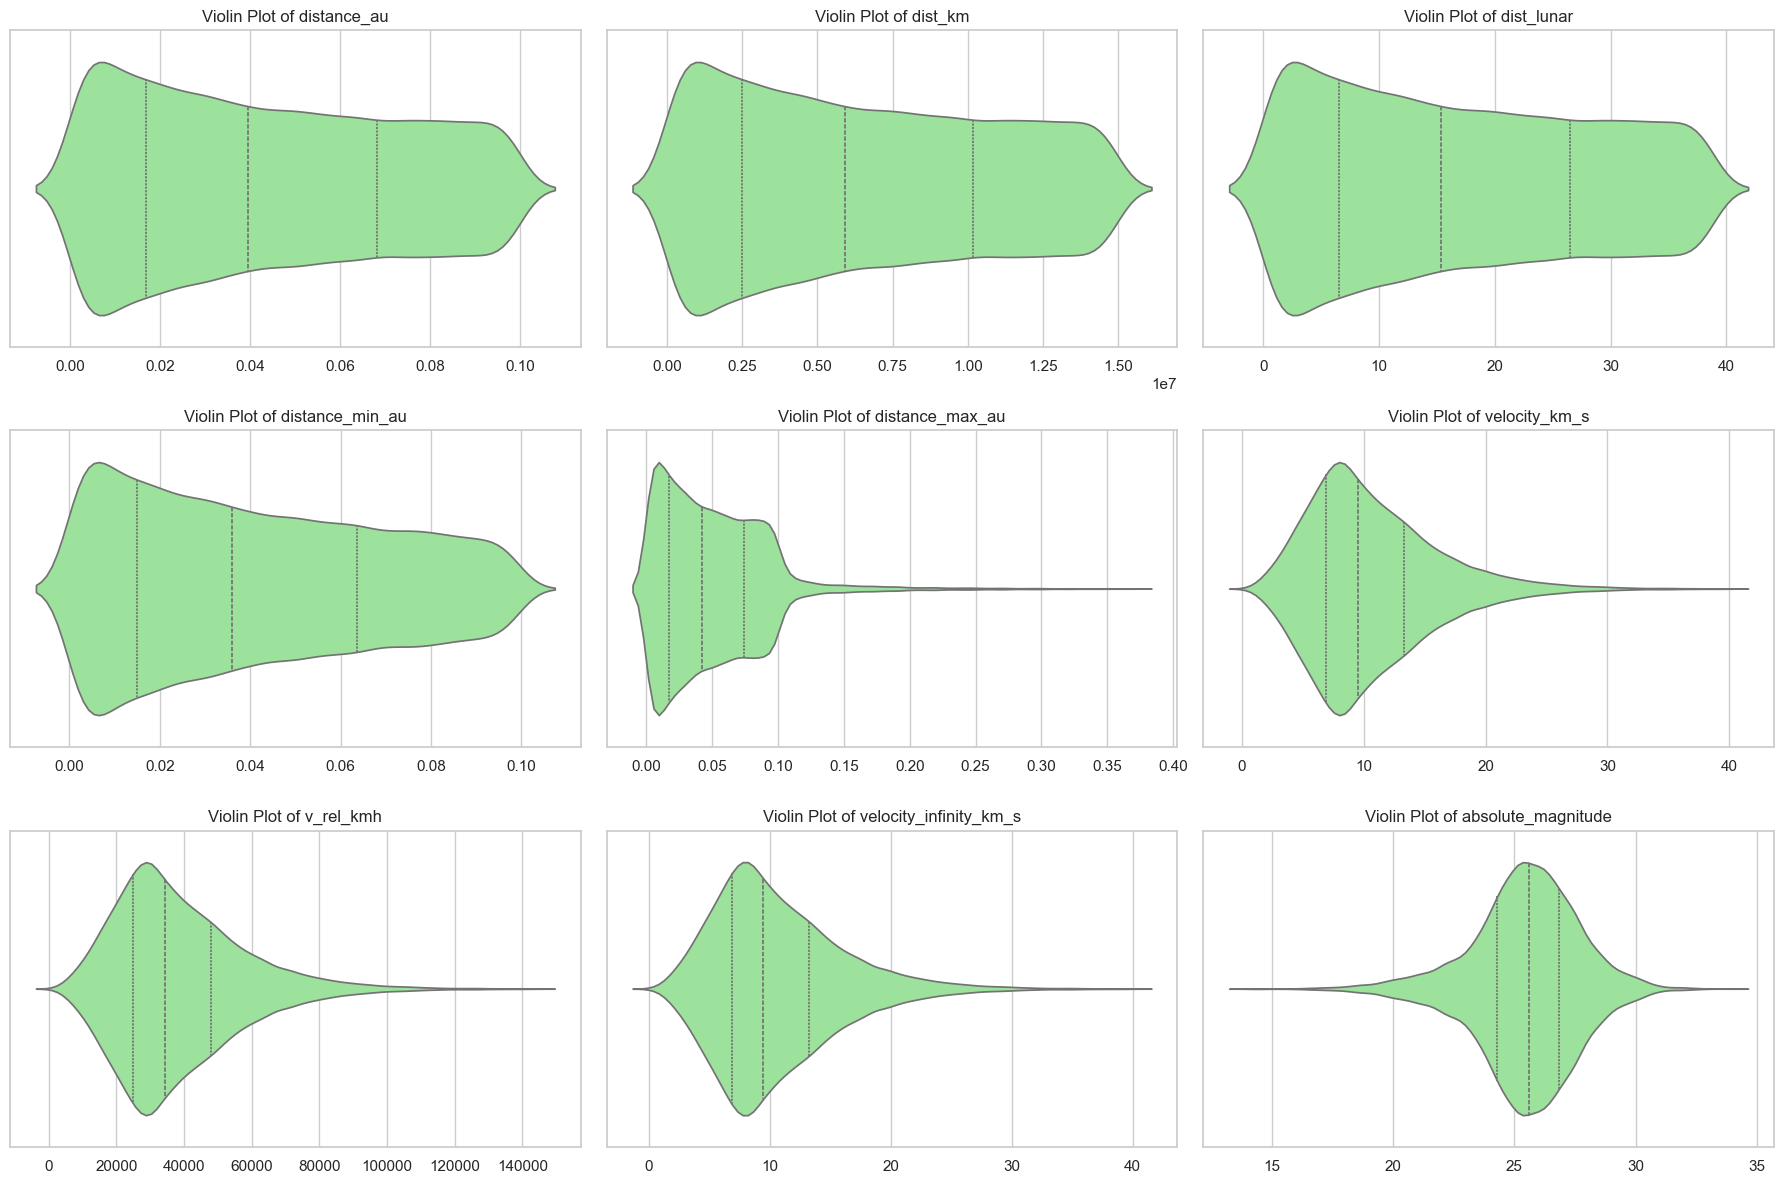

In [44]:
features = [
    'distance_au', 'dist_km', 'dist_lunar', 'distance_min_au', 
    'distance_max_au', 'velocity_km_s', 'v_rel_kmh', 
    'velocity_infinity_km_s', 'absolute_magnitude'
]

fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(18, 12))
axes = axes.flatten()

for i, feat_name in enumerate(features):
    sns.violinplot(
        data=df, 
        x=feat_name, 
        color='lightgreen',
        ax=axes[i],
        inner="quartile"  # THIS adds the quantile lines inside the violin!
    )
    
    axes[i].set_title(f'Violin Plot of {feat_name}')
    axes[i].set_xlabel('') 

plt.tight_layout()
plt.show()